In [1]:
# import packages
from netCDF4 import Dataset
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rc('font',size=14) #set default font size and weight for plots

In [26]:
# the data we will use is described here
# http://www.ncdc.noaa.gov/data-access/marineocean-data/extended-reconstructed-sea-surface-temperature-ersst-v5
# It is stored in the IRI data library
iri_url = "http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCDC/.ERSST/.version5/.sst/"
T_convert = "T/[(days)(since)(1960-01-01)]sconcat/streamgridunitconvert/"

# complete url
url = iri_url + T_convert + "dods"

nc = Dataset(url)
sst = nc.variables['sst'][:]
lat = nc.variables['Y'][:]
lon = nc.variables['X'][:]
time = nc.variables['T'][:]

In [10]:
2064/12

172.0

In [38]:
# extract a slightly larger spatial region in space (-30S-30N, 120E-300E) and a restricted time interval (1950-2019)
sst_pac = sst[12*100:-7,0,29:59,60:150]

In [39]:
# compute an anomaly
ssta_pac = sst_pac - sst_pac.mean(axis=0)

In [42]:
# Just to compare, let's subtract the seasonal cycle
sst_pac_clim = np.reshape(sst_pac,(72,12,sst_pac.shape[1],sst_pac.shape[2])).mean(axis=0)
ssta_pac_noseasons = np.reshape(sst_pac,(72,12,sst_pac.shape[1],sst_pac.shape[2])) - sst_pac_clim

# reshape back to time series
ssta_pac_noseasons = np.reshape(ssta_pac_noseasons,(72*12,sst_pac.shape[1],sst_pac.shape[2]))

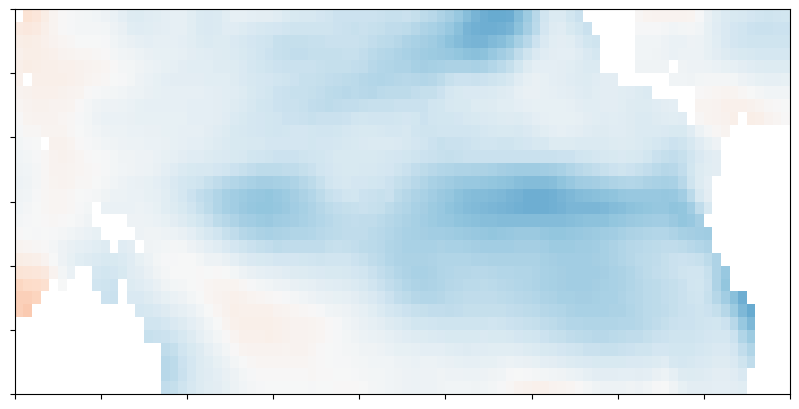

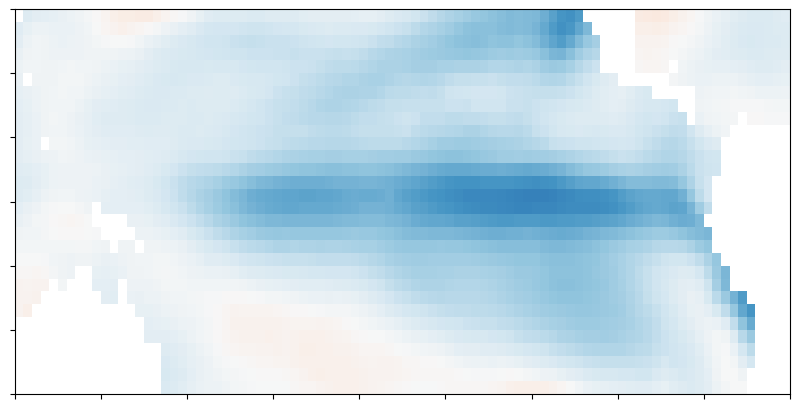

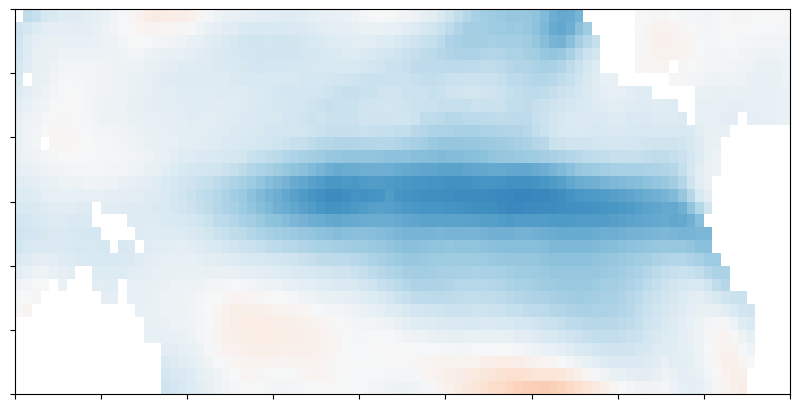

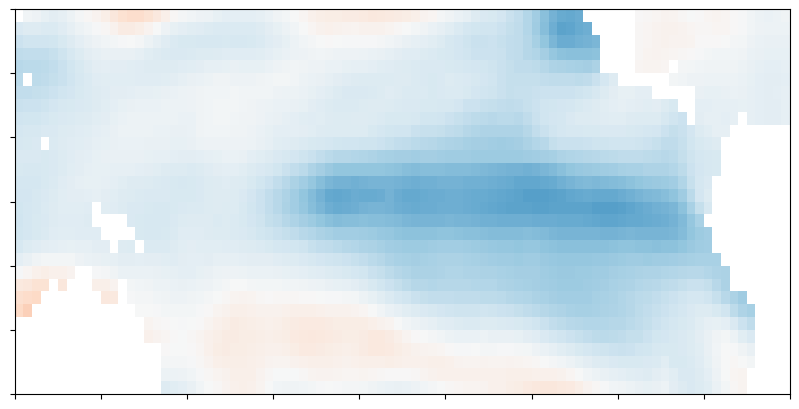

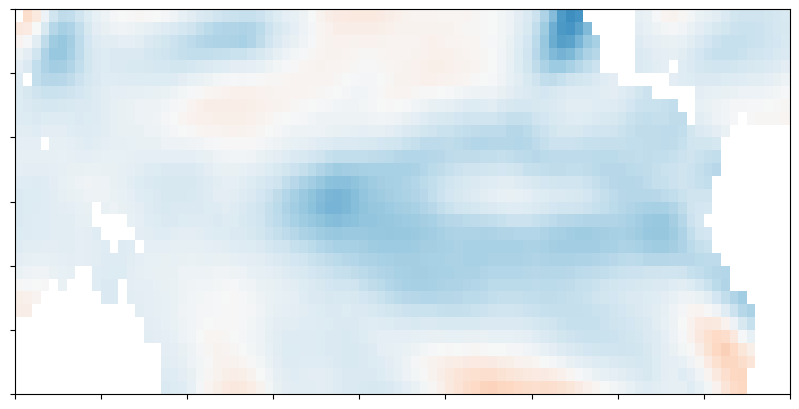

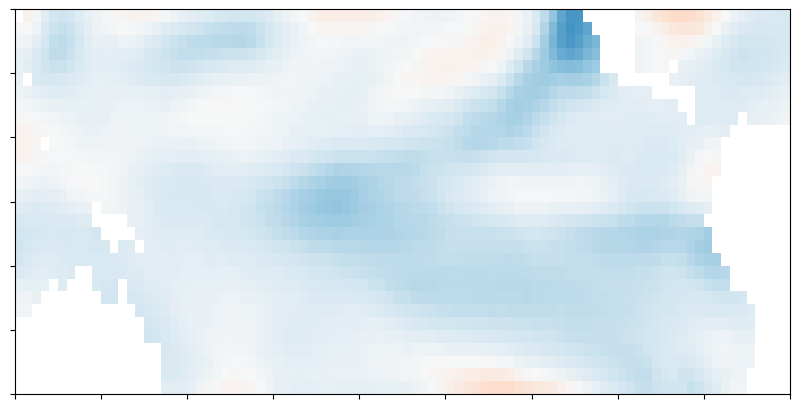

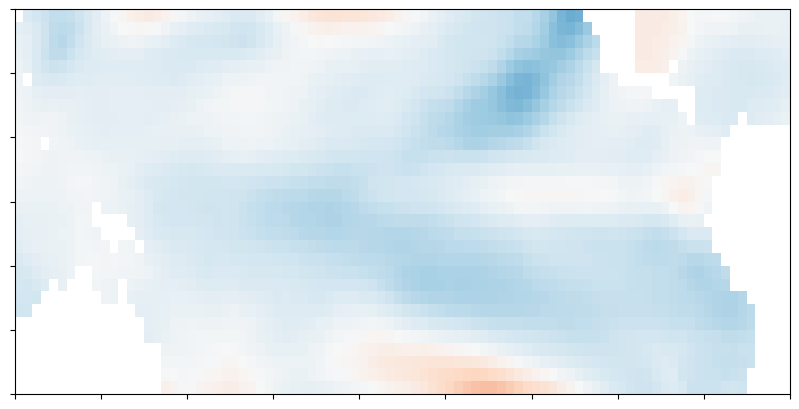

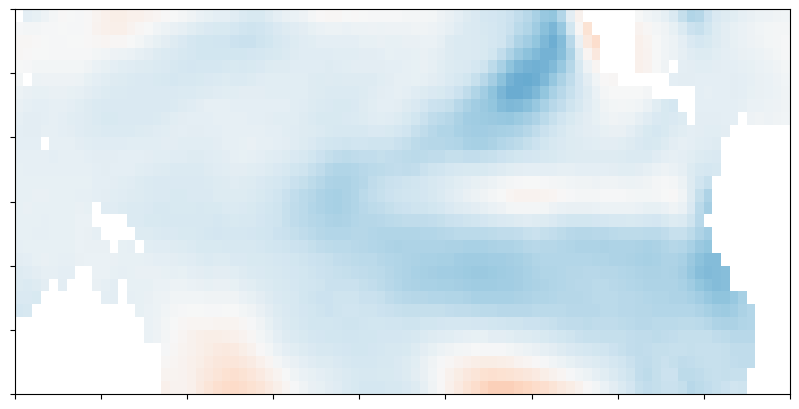

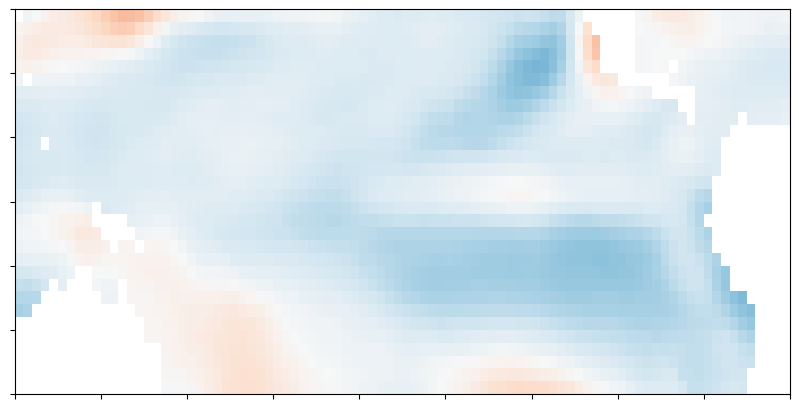

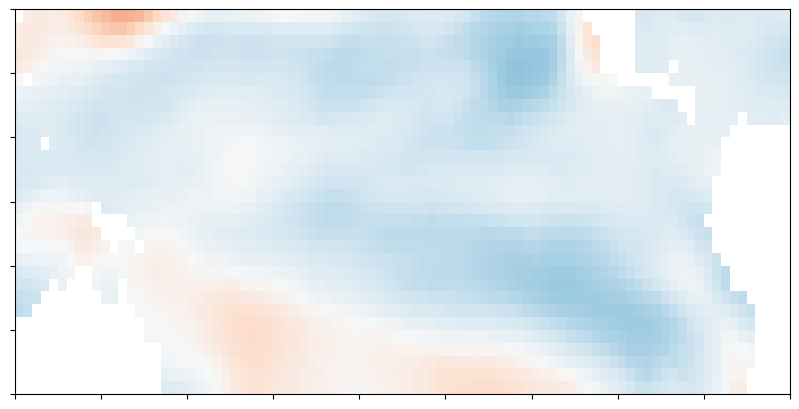

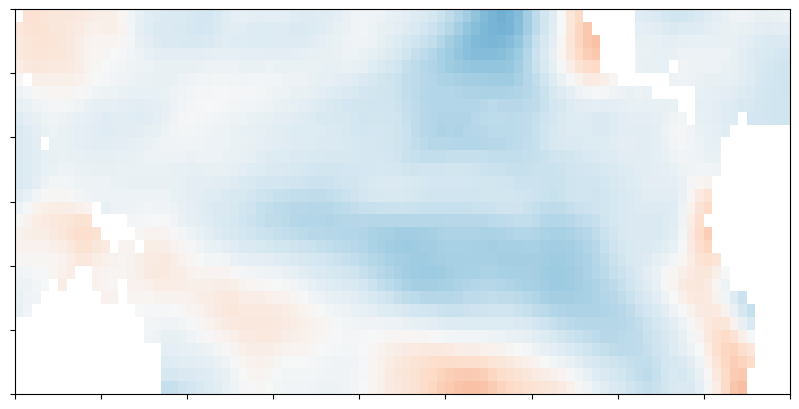

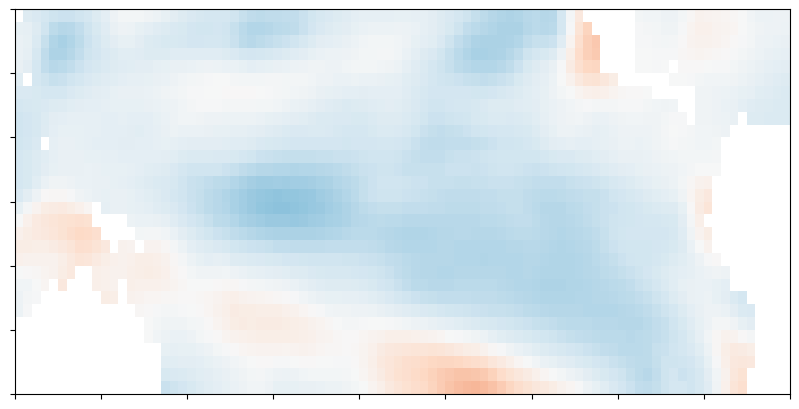

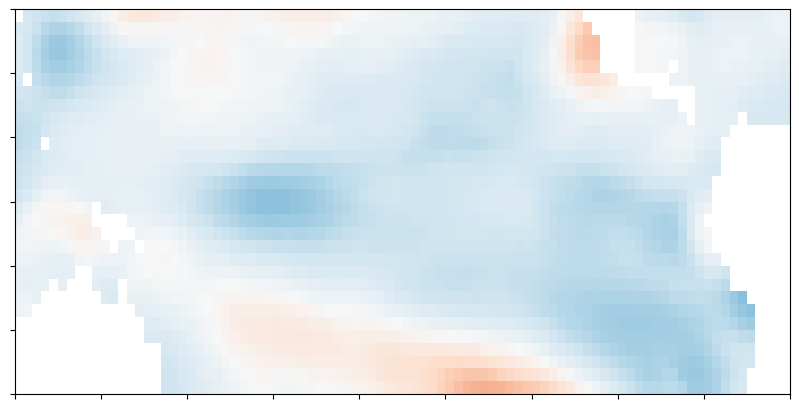

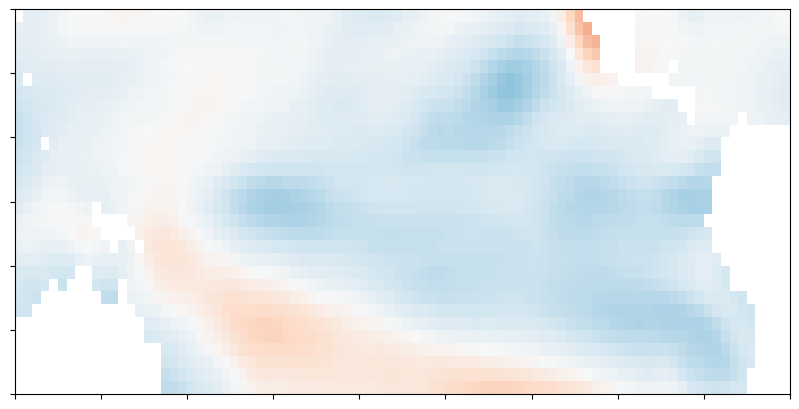

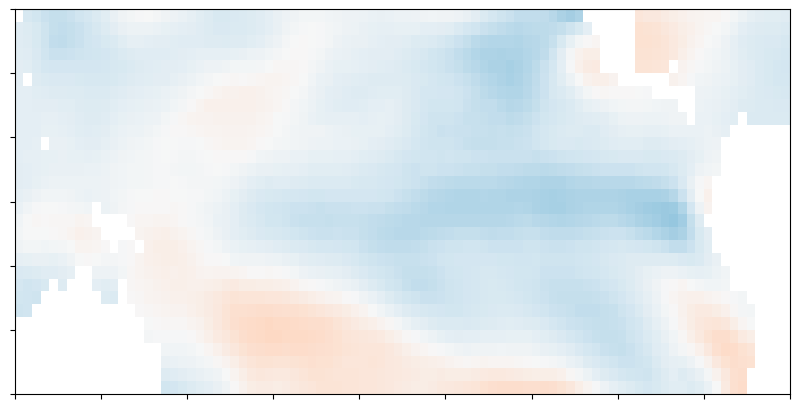

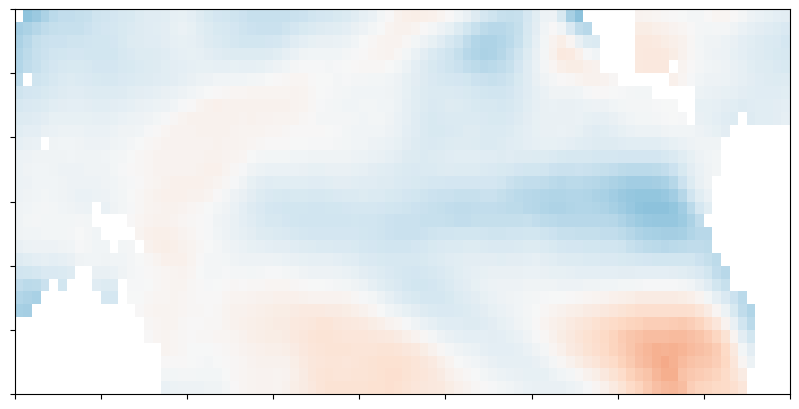

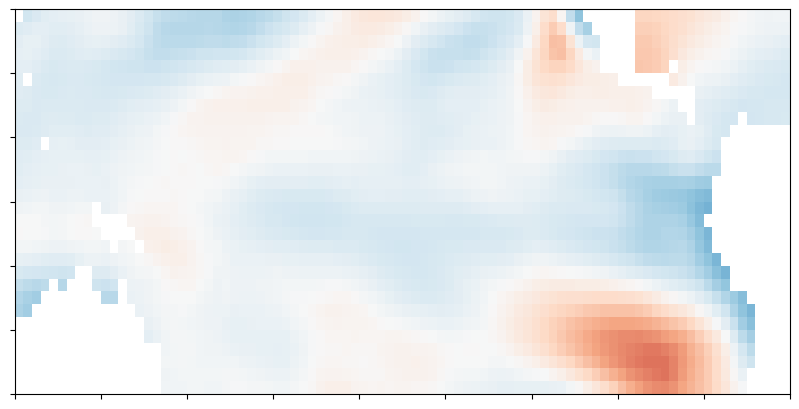

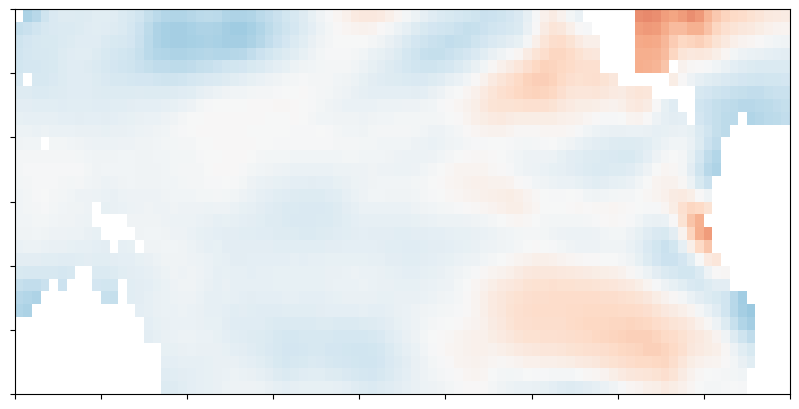

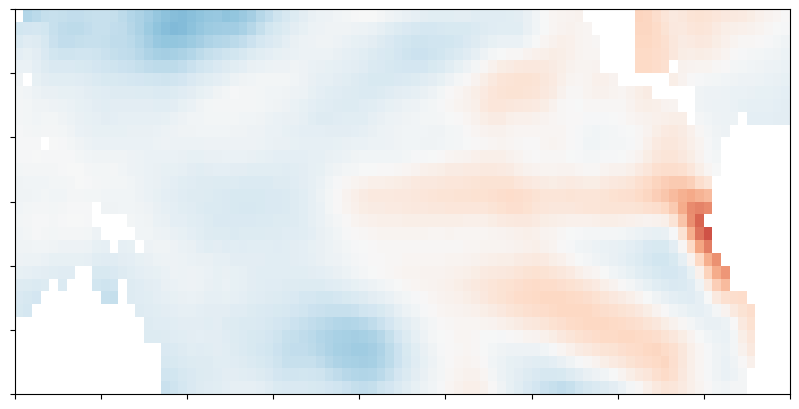

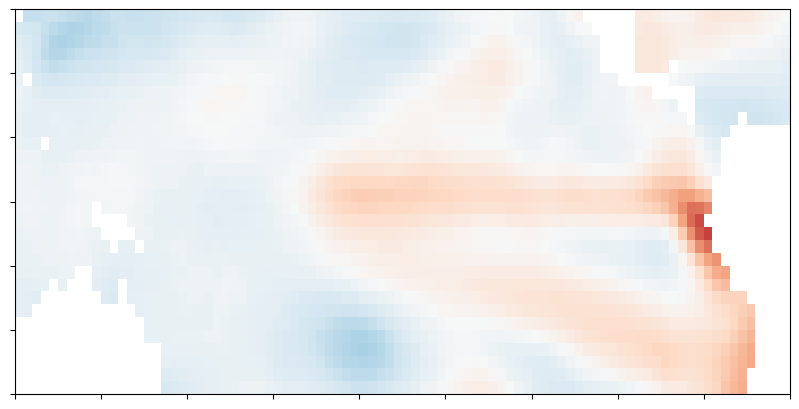

In [48]:
# visualize the region we're working with
for i in range(20):
    plt.figure(figsize=(10,5))
    plt.pcolormesh(ssta_pac_noseasons[i+20,:,:],cmap = "RdBu_r")
    plt.clim(-4,4)
    plt.tick_params(labelbottom=False, labelleft=False)
    #plt.colorbar()
    plt.savefig('ssta_pac_'+str(i)+'.png')